## `DQN_Implementation – Agente DQN para cartera multiactivo con perfil de usuario`

En este cuaderno implementamos nuestro agente Deep Q-Network (DQN) para gestionar una cartera formada por SPY, QQQ, TLT y GLD. Definimos el entorno de cartera multiactivo con episodios de un año, costes de transacción y una función de recompensa que combina rentabilidad relativa frente a SPY y penalización por riesgo según la aversión del usuario. Entrenamos la red neuronal con *replay buffer* y *target network* sobre el tramo de entrenamiento y, finalmente, evaluamos la política aprendida en datos de test para distintos perfiles de aversión al riesgo, comparando siempre el resultado con la estrategia buy & hold.

## 1. Importamos librerias

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

C:\Users\34665\AppData\Local\Temp\ipykernel_28784\2688077881.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## `2. Preparación de los datos`

Descargamos 4 activos: SPY (S&P 500), QQQ (Nasdaq 100), TLT (bonos), GLD (oro).
Calculamos los log-returns y la volatilidad móvil de 20 días como métricas internas de percepción del riesgo.

In [2]:
def get_autonomous_data():
    tickers = ['SPY', 'QQQ', 'TLT', 'GLD']
    start_date = "2010-01-01"
    end_date = "2025-01-01"
    
    print(f"Downloading data for {tickers}...")
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
    
    # Usamos precios de cierre 'Close'  
    df_close = data['Close']
    
    # valores nulos/faltantes
    df_close = df_close.ffill().dropna()
    
    # Calculamos Log Returns
    df_log_ret = np.log(df_close / df_close.shift(1))
    
    # Calcular la volatilidad móvil (desviación estándar de 20 días de los retornos logarítmicos)
    # Proxy de volatilidad anualizada: std * sqrt(252), pero la std bruta es suficiente como entrada relativa
    df_vol = df_log_ret.rolling(window=20).std()
    
    # Combinamos features
    # La estructura será: [Ret_SPY, Ret_QQQ, ..., Vol_SPY, Vol_QQQ, ...]
    features = pd.concat([df_log_ret, df_vol], axis=1)
    features.columns = [f'{col}_ret' for col in df_log_ret.columns] + [f'{col}_vol' for col in df_vol.columns]
    
    # Quitamos los nulos
    features = features.dropna()
    
    # Para calcular el valor de portfolio 
    prices = df_close.loc[features.index]
    
    print(f"Data shape: {features.shape}")
    return prices, features

prices, features = get_autonomous_data()
# Split temporal: 80% train, 20% test
split_ratio = 0.8
split_idx = int(len(features) * split_ratio)

train_prices   = prices.iloc[:split_idx].copy()
train_features = features.iloc[:split_idx].copy()
test_prices    = prices.iloc[split_idx:].copy()
test_features  = features.iloc[split_idx:].copy()

print("Train:", train_features.index[0], "→", train_features.index[-1])
print("Test :", test_features.index[0],  "→", test_features.index[-1])



features.head()

[*********************100%***********************]  4 of 4 completed

Data shape: (3754, 8)
Train: 2010-02-02 00:00:00 → 2022-01-04 00:00:00
Test : 2022-01-05 00:00:00 → 2024-12-31 00:00:00


,GLD_ret,QQQ_ret,SPY_ret,TLT_ret,GLD_vol,QQQ_vol,SPY_vol,TLT_vol
Date,,,,,,,,
2010-02-02,0.007173,0.008975,0.012031,0.002848,0.011791,0.012731,0.010619,0.008259
2010-02-03,-0.003948,0.005483,-0.004995,-0.011664,0.011819,0.012859,0.010606,0.008603
2010-02-04,-0.040649,-0.029363,-0.031352,0.015703,0.014186,0.014160,0.012480,0.008675
2010-02-05,0.002966,0.008411,0.002065,0.002177,0.014236,0.014398,0.012421,0.008677
2010-02-08,-0.006133,-0.007239,-0.007245,0.001304,0.014132,0.014145,0.012344,0.008665


## 3. Entorno (`PortfolioEnv`)

- **Estado**: Datos de Mercado (8) + Pesos de la Cartera (5) + Precio de Compra Promedio (4) + Contexto de Usuario (2) = **19 dimensiones**.
- **Acciones**: 9 acciones discretas:
    - `0`: Mantener (*Hold*)
    - `1-4`: Comprar 10% (*Buy*)
    - `5-8`: Vender 10% (*Sell*)


In [4]:
class PortfolioEnv(gym.Env):
    """
    Entorno de cartera multiactivo:
      - Activos: columnas de `prices` (p.ej. ['GLD', 'QQQ', 'SPY', 'TLT'])
      - Estado: retornos + volatilidades + estado de cartera + avg buy price + contexto usuario
      - Acciones: 0 = Hold; 1-4 = Buy 10% del valor total en activo i; 5-8 = Sell 10% del holding en activo i
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, prices, features, initial_balance=10000,
                 episode_length=252, transaction_cost_rate=0.001):
        super(PortfolioEnv, self).__init__()
        
        self.prices = prices
        self.features = features
        self.initial_balance = initial_balance

        self.assets = prices.columns.tolist()
        self.n_assets = len(self.assets)

        # Parámetros de episodio
        self.episode_length = episode_length
        self.max_steps = len(features) - 1
        self.transaction_cost_rate = transaction_cost_rate
        
        # Espacio de acciones: 0=Hold, 1-4=Buy 10% Asset i, 5-8=Sell 10% Asset i
        self.action_space = spaces.Discrete(1 + 2 * self.n_assets)
        
        # Espacio de observaciones: 
        # 8 Market (4 ret + 4 vol) + 5 Portfolio (1 cash + 4 weights) + 4 AvgBuyPrice + 2 Contexto
        self.input_dims = (2 * self.n_assets) + (1 + self.n_assets) + self.n_assets + 2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.input_dims,), dtype=np.float32
        )
        
        # Estado interno
        self.current_step = 0
        self.end_step = 0
        self.balance = None
        self.holdings = None
        self.avg_buy_price = None
        self.portfolio_value = None
        self.portfolio_history = None
        self.weight_history = None

        # Contexto de usuario
        self.risk_aversion = None
        self.time_horizon = None
        
    def reset(self, seed=None, options=None):

        super().reset(seed=seed)
        
        # Elegimos punto de inicio aleatorio del episodio (solo TRAIN usará esta lógica)
        max_start = self.max_steps - self.episode_length
        if max_start <= 0:
            self.current_step = 0
            self.end_step = self.max_steps
        else:
            self.current_step = np.random.randint(0, max_start)
            self.end_step = self.current_step + self.episode_length
        
        self.balance = self.initial_balance
        self.holdings = np.zeros(self.n_assets)
        self.avg_buy_price = np.zeros(self.n_assets)
        self.portfolio_value = self.initial_balance
        self.portfolio_history = [self.initial_balance]
        self.weight_history = []
        
        self.risk_aversion = np.random.uniform(0, 1)  # 0 = agresivo, 1 = conservador
        self.time_horizon = np.random.uniform(0, 1)   # horizonte normalizado
        
        self.n_buys = 0
        self.n_sells = 0
        self.n_holds = 0

        
        return self._get_state(), {}
    
    def _get_state(self):
        # 1. Datos de mercado (retornos + volatilidades)
        market_data = self.features.iloc[self.current_step].values
        
        # 2. Estado de cartera
        current_prices = self.prices.iloc[self.current_step].values
        asset_values = self.holdings * current_prices
        total_value = self.balance + np.sum(asset_values)
        
        # weights: [peso_cash, peso_activo1, ..., peso_activoN]
        weights = np.concatenate(([self.balance], asset_values)) / total_value
        
        # 3. Memoria: avg buy price relativa al precio actual
        price_ratios = np.zeros(self.n_assets)
        for i in range(self.n_assets):
            if self.avg_buy_price[i] > 0:
                price_ratios[i] = current_prices[i] / self.avg_buy_price[i]
            else:
                price_ratios[i] = 1.0  # sin posición
        
        # 4. Contexto usuario
        context = np.array([self.risk_aversion, self.time_horizon])
        
        state = np.concatenate((market_data, weights, price_ratios, context))
        return state.astype(np.float32)
    
    def step(self, action):
        current_prices = self.prices.iloc[self.current_step].values
        
        # Valor total previo
        prev_total_value = self.portfolio_history[-1]
        
        # Ejecutamos acción
        if action > 0:
            asset_idx = (action - 1) % self.n_assets
            is_buy = (action - 1) < self.n_assets
            
            if is_buy:
                # Comprar 10% del valor total
                total_value = self.balance + np.sum(self.holdings * current_prices)
                trade_amount = 0.1 * total_value
                
                if self.balance >= trade_amount:
                    # Coste de transacción
                    effective_amount = trade_amount * (1.0 - self.transaction_cost_rate)
                    shares = effective_amount / current_prices[asset_idx]
                    
                    total_cost = (self.holdings[asset_idx] * self.avg_buy_price[asset_idx]) + effective_amount
                    self.holdings[asset_idx] += shares
                    self.avg_buy_price[asset_idx] = total_cost / self.holdings[asset_idx]
                    self.balance -= trade_amount  # el coste se descuenta de la cartera
                    
            else:
                # Vender 10% de la posición en ese activo
                if self.holdings[asset_idx] > 0:
                    shares_to_sell = 0.1 * self.holdings[asset_idx]
                    gross = shares_to_sell * current_prices[asset_idx]
                    net = gross * (1.0 - self.transaction_cost_rate)
                    
                    self.holdings[asset_idx] -= shares_to_sell
                    self.balance += net
                    
                    if self.holdings[asset_idx] < 1e-6:
                        self.holdings[asset_idx] = 0.0
                        self.avg_buy_price[asset_idx] = 0.0
        
        # Avanzamos un paso
        self.current_step += 1
        terminated = self.current_step >= self.end_step
        truncated = False
        
        # Nuevo valor de la cartera
        new_prices = self.prices.iloc[self.current_step].values
        new_total_value = self.balance + np.sum(self.holdings * new_prices)
        
        # Rentabilidad diaria de la cartera
        daily_ret = (new_total_value - prev_total_value) / (prev_total_value + 1e-8)

        # Rentabilidad diaria del benchmark (SPY)
        # Usamos precios "antes" (current_prices) y "después" (new_prices) para evitar líos de índices
        if "SPY" in self.assets:
            spy_idx = self.assets.index("SPY")
            spy_prev = current_prices[spy_idx]
            spy_new = new_prices[spy_idx]
            spy_ret = (spy_new - spy_prev) / (spy_prev + 1e-8)
        else:
            spy_ret = 0.0  # si no hay SPY, el benchmark queda neutro

        # Proxy de volatilidad de cartera: weighted average de volatilidades individuales
        current_vols = self.features.iloc[self.current_step][
            [c for c in self.features.columns if '_vol' in c]
        ].values

        asset_values = self.holdings * new_prices
        total_value_now = self.balance + np.sum(asset_values)

        asset_weights = np.zeros_like(asset_values)
        if total_value_now > 0:
            asset_weights = asset_values / total_value_now

        portfolio_vol_proxy = np.sum(asset_weights * current_vols)

        # Penalización por riesgo (baja el peso para no empujar al agente a cash)
        risk_penalty = self.risk_aversion * portfolio_vol_proxy * 0.02

        # Reward relativa: batir a SPY
        reward_raw = (daily_ret - spy_ret) - risk_penalty
        reward = float(np.clip(reward_raw * 100.0, -10.0, 10.0))
        
        # Históricos
        self.portfolio_history.append(new_total_value)
        self.weight_history.append(
            np.concatenate(([self.balance], asset_values)) / (new_total_value if new_total_value > 0 else 1.0)
        )
        
        info = {"n_buys": self.n_buys, "n_sells": self.n_sells, "n_holds": self.n_holds}

        return self._get_state(), reward, terminated, truncated, info
        
    def render(self):
        # Aquí podríamos pintar la curva, pesos, etc. si lo necesitamos
        pass


## 4. Agente DQN

Red MLP simple con replay buffer

In [5]:
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, output_dim)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        return self.fc4(x)

class DQNAgent:
    def __init__(self, input_dim, output_dim, lr=1e-3, gamma=0.99, epsilon_start=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = DQN(input_dim, output_dim).to(self.device)
        self.target_net = DQN(input_dim, output_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.memory = deque(maxlen=10000)
        self.batch_size = 64
        
    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.output_dim)
        
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state)
        return q_values.argmax().item()
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)
        
        current_q = self.policy_net(states).gather(1, actions)
        
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + (self.gamma * next_q * (1 - dones))
            
        loss = self.loss_fn(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

## 5. Training Loop

In [6]:
# Entorno de entrenamiento: episodios ~1 año
env_train = PortfolioEnv(
    train_prices,
    train_features,
    initial_balance=10000,
    episode_length=252,
    transaction_cost_rate=0.001
)

# Entorno de test: usaremos todo el tramo en evaluación (ajustaremos end_step allí)
env_test = PortfolioEnv(
    test_prices,
    test_features,
    initial_balance=10000,
    episode_length=len(test_features) - 1,
    transaction_cost_rate=0.001
)

# Agente DQN
agent = DQNAgent(env_train.input_dims, env_train.action_space.n, epsilon_decay=0.995)
agent.epsilon_min = 0.05  


episodes = 500
rewards_history = []

print("Starting Training...")
for e in range(episodes):
    state, _ = env_train.reset()
    total_reward = 0.0
    done = False
    
    while not done:
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated
        
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
        agent.replay()

    # Decay epsilon: una vez por episodio
    agent.epsilon = max(agent.epsilon_min, agent.epsilon * agent.epsilon_decay)
        
    if e % 10 == 0:
        agent.update_target_network()
        print(f"Episode {e}/{episodes}, Total Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.2f}")
    
    rewards_history.append(total_reward)


print("Training Complete.")


Starting Training...
Episode 0/500, Total Reward: -10.21, Epsilon: 0.99
Episode 10/500, Total Reward: -7.62, Epsilon: 0.95
Episode 20/500, Total Reward: -6.01, Epsilon: 0.90
Episode 30/500, Total Reward: 7.77, Epsilon: 0.86
Episode 40/500, Total Reward: -1.85, Epsilon: 0.81
Episode 50/500, Total Reward: -2.85, Epsilon: 0.77
Episode 60/500, Total Reward: -34.17, Epsilon: 0.74
Episode 70/500, Total Reward: 7.28, Epsilon: 0.70
Episode 80/500, Total Reward: -18.19, Epsilon: 0.67
Episode 90/500, Total Reward: -3.86, Epsilon: 0.63
Episode 100/500, Total Reward: -11.31, Epsilon: 0.60
Episode 110/500, Total Reward: -16.18, Epsilon: 0.57
Episode 120/500, Total Reward: -13.70, Epsilon: 0.55
Episode 130/500, Total Reward: -10.57, Epsilon: 0.52
Episode 140/500, Total Reward: 12.65, Epsilon: 0.49
Episode 150/500, Total Reward: -20.31, Epsilon: 0.47
Episode 160/500, Total Reward: -14.78, Epsilon: 0.45
Episode 170/500, Total Reward: -6.82, Epsilon: 0.42
Episode 180/500, Total Reward: -43.78, Epsilon:

AVERSIÓN AL RIESGO BAJA (MUY AGRESIVO)

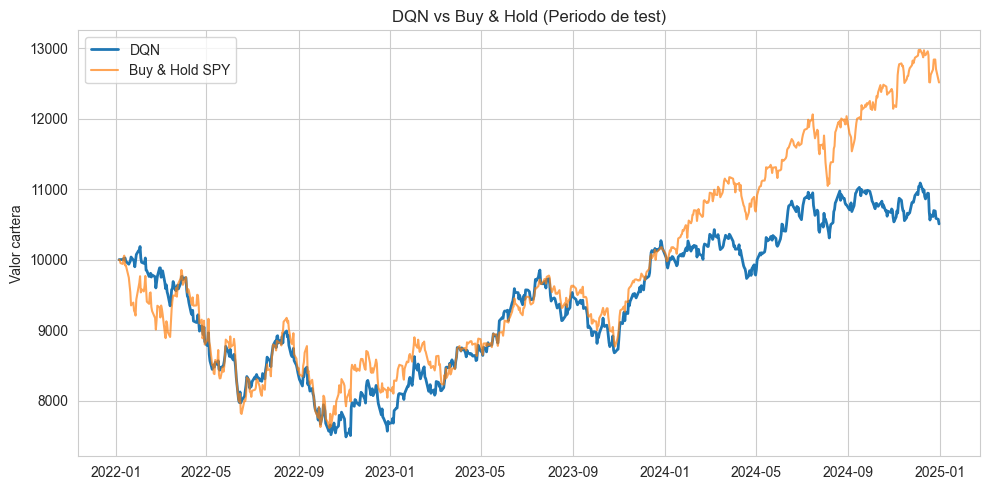

In [7]:
# --- Evaluación en datos de test (policy greedy, sin entrenamiento) ---

agent.epsilon = 0.0  # greedy para evaluar

# 1) Reset del entorno de test
state, _ = env_test.reset(seed=SEED)

# 2) Fijamos la aversión al riesgo del usuario para TODO el episodio de test
desired_risk_aversion = 0.1   # por ejemplo: 0.2 agresivo, 0.5 medio, 0.8 conservador
env_test.risk_aversion = desired_risk_aversion

# (opcional pero fino) recomputar el estado inicial para que incluya el nuevo valor:
state = env_test._get_state()

# 3) Forzamos que el episodio recorra TODO el tramo de test
env_test.current_step = 0
env_test.end_step = env_test.max_steps

done = False
values_dqn = [env_test.initial_balance]
dates = [env_test.features.index[env_test.current_step]]

while not done:
    action = agent.act(state)
    next_state, reward, terminated, truncated, _ = env_test.step(action)
    done = terminated or truncated

    values_dqn.append(env_test.portfolio_history[-1])
    dates.append(env_test.features.index[env_test.current_step])

    state = next_state


equity_dqn = pd.Series(values_dqn, index=dates)

# Benchmark: buy & hold en SPY (mismo periodo de test)
spy_test = test_prices["SPY"]
equity_bh = (spy_test / spy_test.iloc[0]) * env_test.initial_balance

plt.figure(figsize=(10,5))
plt.plot(equity_dqn.index, equity_dqn.values, label="DQN", linewidth=2)
plt.plot(equity_bh.index, equity_bh.values, label="Buy & Hold SPY", alpha=0.7)
plt.title("DQN vs Buy & Hold (Periodo de test)")
plt.ylabel("Valor cartera")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


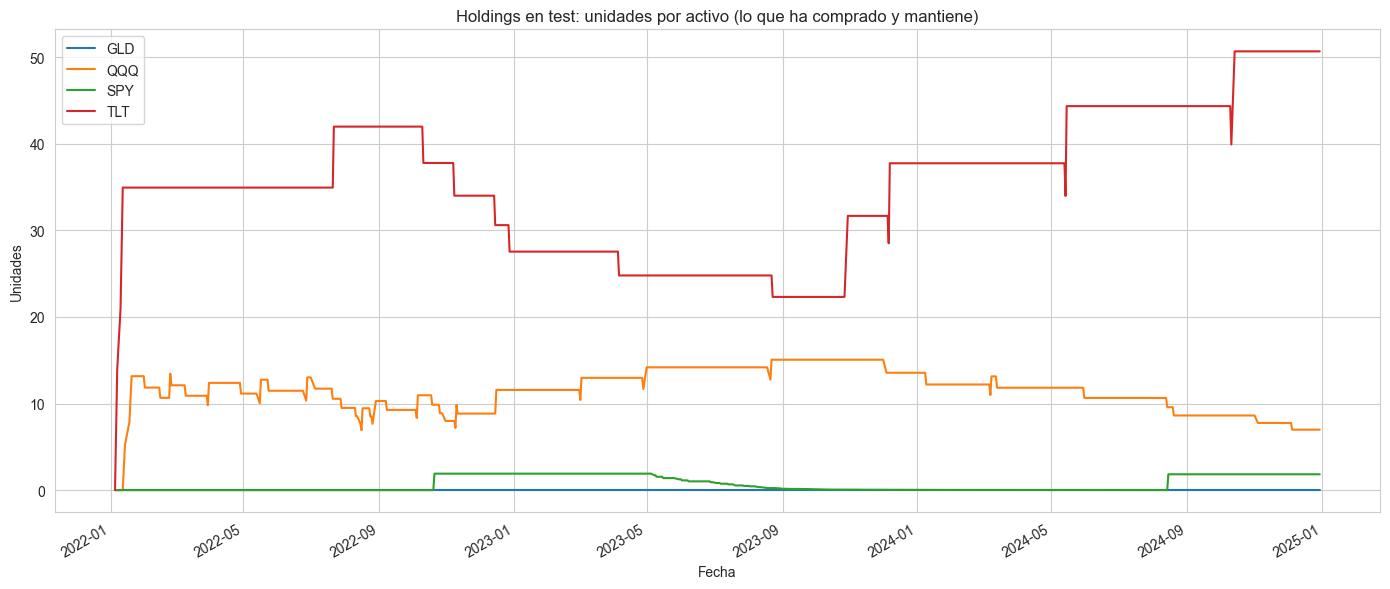

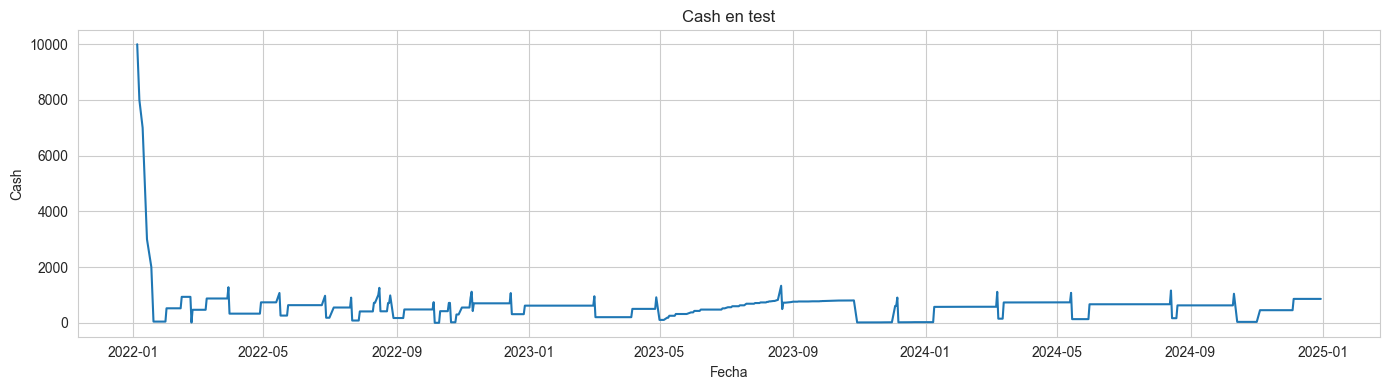

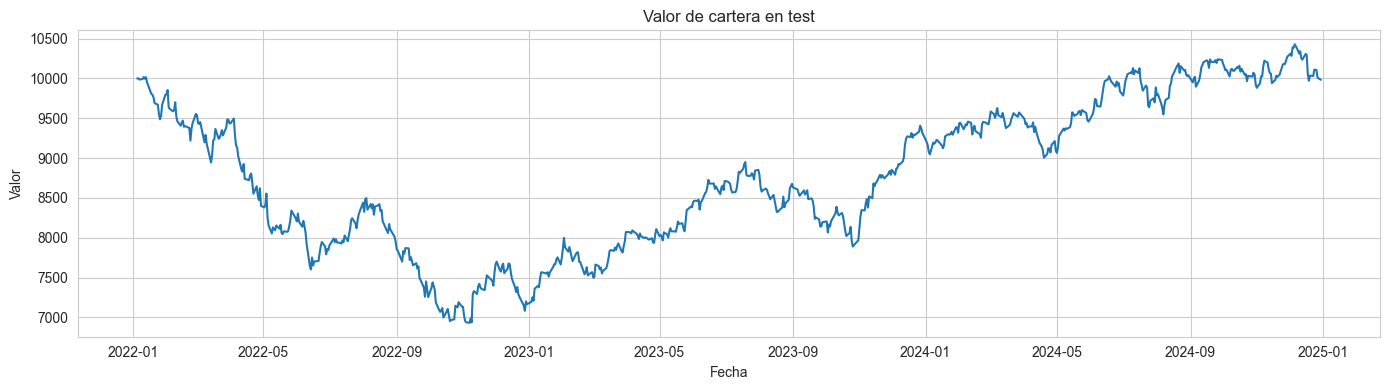

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_test_holdings(env_test, agent, greedy=True):
    """
    Ejecuta un episodio completo en env_test y grafica:
      - Unidades (holdings) de cada activo a lo largo del tiempo.
      - (Opcional) cash y valor de cartera.

    Funciona con tu PortfolioEnv (usa env_test.holdings, env_test.balance, env_test.portfolio_history).
    """
    # Forzamos política greedy en test si se pide
    eps_backup = getattr(agent, "epsilon", None)
    if greedy and eps_backup is not None:
        agent.epsilon = 0.0

    state, _ = env_test.reset()
    done = False

    dates = []
    holdings_hist = []
    cash_hist = []
    portval_hist = []

    while True:
        # Guardamos el estado actual (antes del step) para no salirnos del índice
        dates.append(env_test.features.index[env_test.current_step])
        holdings_hist.append(env_test.holdings.copy())
        cash_hist.append(float(env_test.balance))
        portval_hist.append(float(env_test.portfolio_history[-1]))

        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env_test.step(action)
        state = next_state
        done = terminated or truncated

        if done:
            break

    # Restaurar epsilon
    if greedy and eps_backup is not None:
        agent.epsilon = eps_backup

    # DataFrame con holdings
    holdings_df = pd.DataFrame(holdings_hist, index=dates, columns=env_test.assets)

    # Gráfica holdings por activo
    ax = holdings_df.plot(figsize=(14, 6))
    ax.set_title("Holdings en test: unidades por activo (lo que ha comprado y mantiene)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Unidades")
    plt.tight_layout()
    plt.show()

    # Opcional: cash y valor de cartera 
    plt.figure(figsize=(14, 4))
    plt.plot(dates, cash_hist)
    plt.title("Cash en test")
    plt.xlabel("Fecha")
    plt.ylabel("Cash")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(dates, portval_hist)
    plt.title("Valor de cartera en test")
    plt.xlabel("Fecha")
    plt.ylabel("Valor")
    plt.tight_layout()
    plt.show()

    return holdings_df

holdings_df = plot_test_holdings(env_test, agent, greedy=True)


RIESGO MEDIO

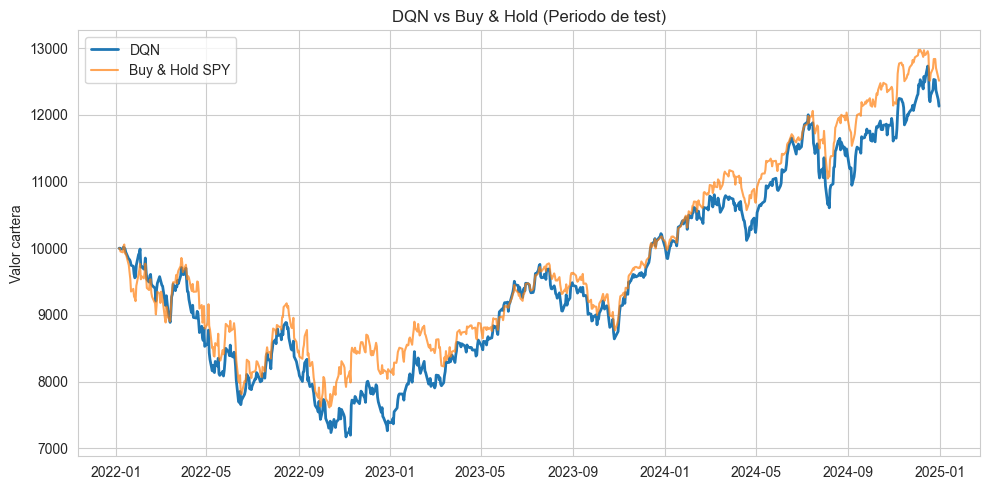

In [9]:
# --- Evaluación en datos de test (policy greedy, sin entrenamiento) ---

agent.epsilon = 0.0  # greedy para evaluar

# 1) Reset del entorno de test
state, _ = env_test.reset(seed=SEED)

# 2) Fijamos la aversión al riesgo del usuario para TODO el episodio de test
desired_risk_aversion = 0.5   # por ejemplo: 0.2 agresivo, 0.5 medio, 0.8 conservador
env_test.risk_aversion = desired_risk_aversion

# (opcional pero fino) recomputar el estado inicial para que incluya el nuevo valor:
state = env_test._get_state()

# 3) Forzamos que el episodio recorra TODO el tramo de test
env_test.current_step = 0
env_test.end_step = env_test.max_steps

done = False
values_dqn = [env_test.initial_balance]
dates = [env_test.features.index[env_test.current_step]]

while not done:
    action = agent.act(state)
    next_state, reward, terminated, truncated, _ = env_test.step(action)
    done = terminated or truncated

    values_dqn.append(env_test.portfolio_history[-1])
    dates.append(env_test.features.index[env_test.current_step])

    state = next_state


equity_dqn = pd.Series(values_dqn, index=dates)

# Benchmark: buy & hold en SPY (mismo periodo de test)
spy_test = test_prices["SPY"]
equity_bh = (spy_test / spy_test.iloc[0]) * env_test.initial_balance

plt.figure(figsize=(10,5))
plt.plot(equity_dqn.index, equity_dqn.values, label="DQN", linewidth=2)
plt.plot(equity_bh.index, equity_bh.values, label="Buy & Hold SPY", alpha=0.7)
plt.title("DQN vs Buy & Hold (Periodo de test)")
plt.ylabel("Valor cartera")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


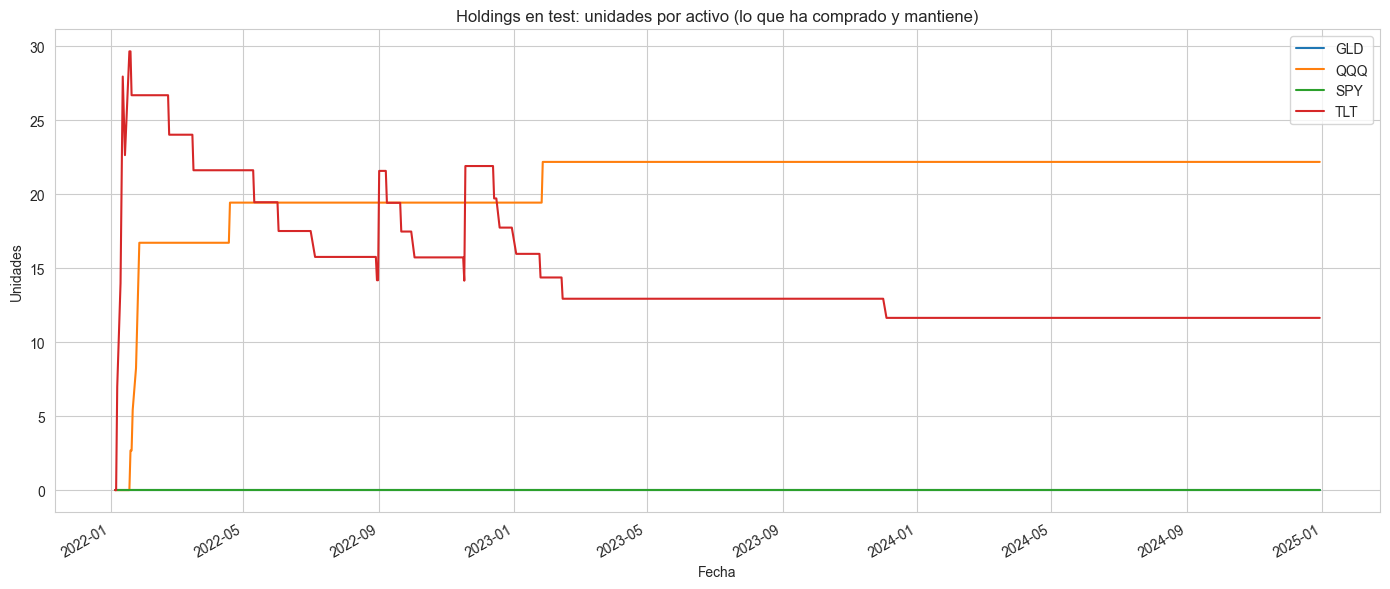

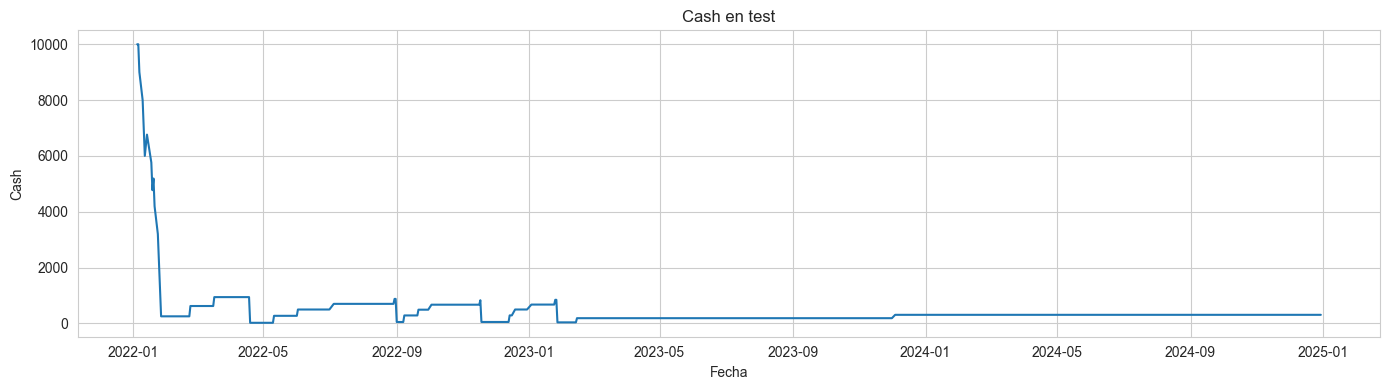

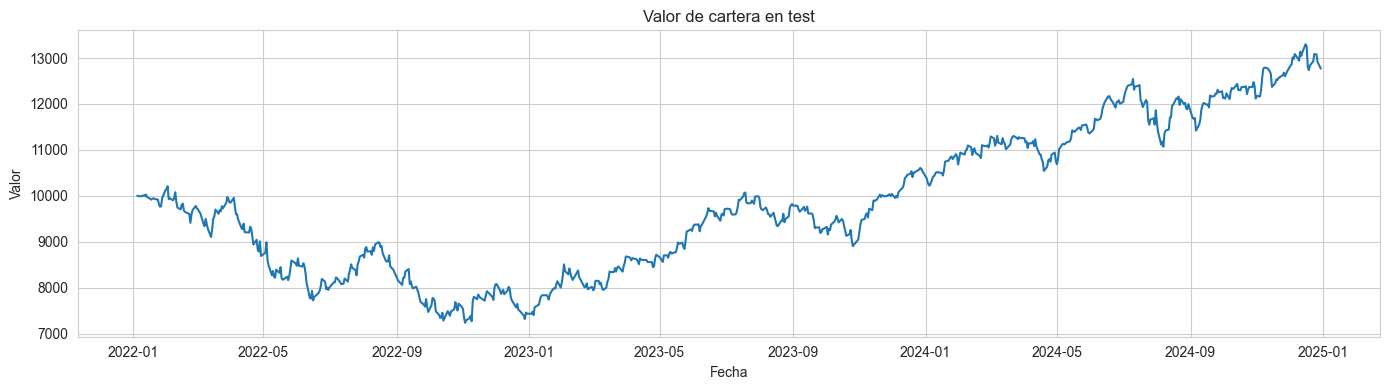

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_test_holdings(env_test, agent, greedy=True):
    """
    Ejecuta un episodio completo en env_test y grafica:
      - Unidades (holdings) de cada activo a lo largo del tiempo.
      - (Opcional) cash y valor de cartera.

    Funciona con tu PortfolioEnv (usa env_test.holdings, env_test.balance, env_test.portfolio_history).
    """
    # Forzamos política greedy en test si se pide
    eps_backup = getattr(agent, "epsilon", None)
    if greedy and eps_backup is not None:
        agent.epsilon = 0.0

    state, _ = env_test.reset()
    done = False

    dates = []
    holdings_hist = []
    cash_hist = []
    portval_hist = []

    while True:
        # Guardamos el estado actual (antes del step) para no salirnos del índice
        dates.append(env_test.features.index[env_test.current_step])
        holdings_hist.append(env_test.holdings.copy())
        cash_hist.append(float(env_test.balance))
        portval_hist.append(float(env_test.portfolio_history[-1]))

        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env_test.step(action)
        state = next_state
        done = terminated or truncated

        if done:
            break

    # Restaurar epsilon
    if greedy and eps_backup is not None:
        agent.epsilon = eps_backup

    # DataFrame con holdings
    holdings_df = pd.DataFrame(holdings_hist, index=dates, columns=env_test.assets)

    # Gráfica holdings por activo
    ax = holdings_df.plot(figsize=(14, 6))
    ax.set_title("Holdings en test: unidades por activo (lo que ha comprado y mantiene)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Unidades")
    plt.tight_layout()
    plt.show()

    # Opcional: cash y valor de cartera 
    plt.figure(figsize=(14, 4))
    plt.plot(dates, cash_hist)
    plt.title("Cash en test")
    plt.xlabel("Fecha")
    plt.ylabel("Cash")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(dates, portval_hist)
    plt.title("Valor de cartera en test")
    plt.xlabel("Fecha")
    plt.ylabel("Valor")
    plt.tight_layout()
    plt.show()

    return holdings_df

holdings_df = plot_test_holdings(env_test, agent, greedy=True)


AVERSION AL RIESGO ALTA (USUARIO MUY CONSERVADOR)

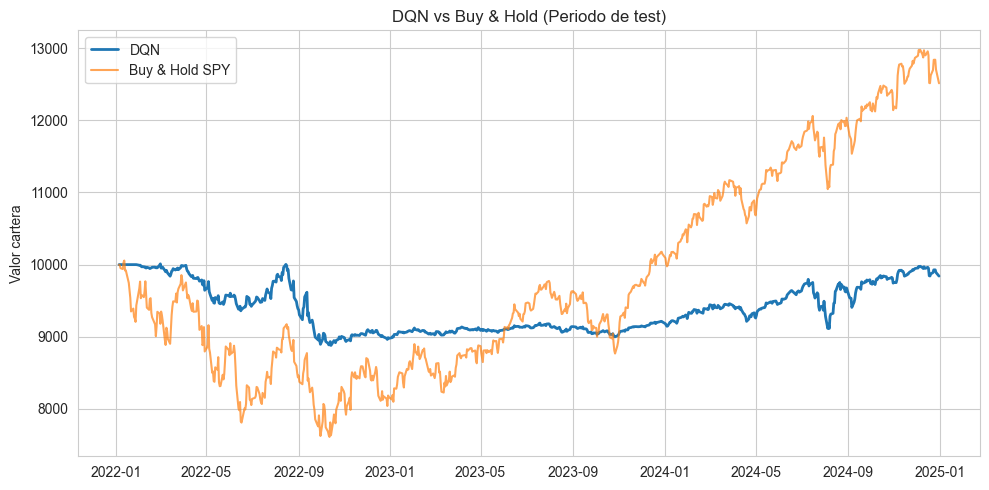

In [15]:
# --- Evaluación en datos de test (policy greedy, sin entrenamiento) ---

agent.epsilon = 0.0  # greedy para evaluar

# 1) Reset del entorno de test
state, _ = env_test.reset(seed=SEED)

# 2) Fijamos la aversión al riesgo del usuario para TODO el episodio de test
desired_risk_aversion = 0.8   # por ejemplo: 0.2 agresivo, 0.5 medio, 0.8 conservador
env_test.risk_aversion = desired_risk_aversion

# (opcional pero fino) recomputar el estado inicial para que incluya el nuevo valor:
state = env_test._get_state()

# 3) Forzamos que el episodio recorra TODO el tramo de test
env_test.current_step = 0
env_test.end_step = env_test.max_steps

done = False
values_dqn = [env_test.initial_balance]
dates = [env_test.features.index[env_test.current_step]]

while not done:
    action = agent.act(state)
    next_state, reward, terminated, truncated, _ = env_test.step(action)
    done = terminated or truncated

    values_dqn.append(env_test.portfolio_history[-1])
    dates.append(env_test.features.index[env_test.current_step])

    state = next_state


equity_dqn = pd.Series(values_dqn, index=dates)

# Benchmark: buy & hold en SPY (mismo periodo de test)
spy_test = test_prices["SPY"]
equity_bh = (spy_test / spy_test.iloc[0]) * env_test.initial_balance

plt.figure(figsize=(10,5))
plt.plot(equity_dqn.index, equity_dqn.values, label="DQN", linewidth=2)
plt.plot(equity_bh.index, equity_bh.values, label="Buy & Hold SPY", alpha=0.7)
plt.title("DQN vs Buy & Hold (Periodo de test)")
plt.ylabel("Valor cartera")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
def compute_metrics(equity_curve: pd.Series):
    if isinstance(equity_curve, pd.DataFrame):
        equity_curve = equity_curve.iloc[:, 0]

    rets = equity_curve.pct_change().dropna()

    total_return = float(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1)

    mean_ret = float(rets.mean())
    std_ret  = float(rets.std())

    if std_ret is None or np.isnan(std_ret) or std_ret == 0.0:
        sharpe = np.nan
    else:
        sharpe = (mean_ret / std_ret) * np.sqrt(252)

    rolling_max = equity_curve.cummax()
    drawdown = equity_curve / rolling_max - 1
    max_dd = float(drawdown.min())

    return {
        "total_return": total_return,
        "annual_vol": std_ret * np.sqrt(252),
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

metrics_dqn = compute_metrics(equity_dqn)
metrics_bh  = compute_metrics(equity_bh)

print("\nMÉTRICAS DQN (test)")
for k, v in metrics_dqn.items():
    print(f"  {k:15s}: {v: .4f}")

print("\nMÉTRICAS Buy & Hold SPY (test)")
for k, v in metrics_bh.items():
    print(f"  {k:15s}: {v: .4f}")



MÉTRICAS DQN (test)
  total_return   :  0.0961
  annual_vol     :  0.0444
  sharpe         :  0.7165
  max_drawdown   : -0.0825

MÉTRICAS Buy & Hold SPY (test)
  total_return   :  0.2513
  annual_vol     :  0.1754
  sharpe         :  0.5172
  max_drawdown   : -0.2430


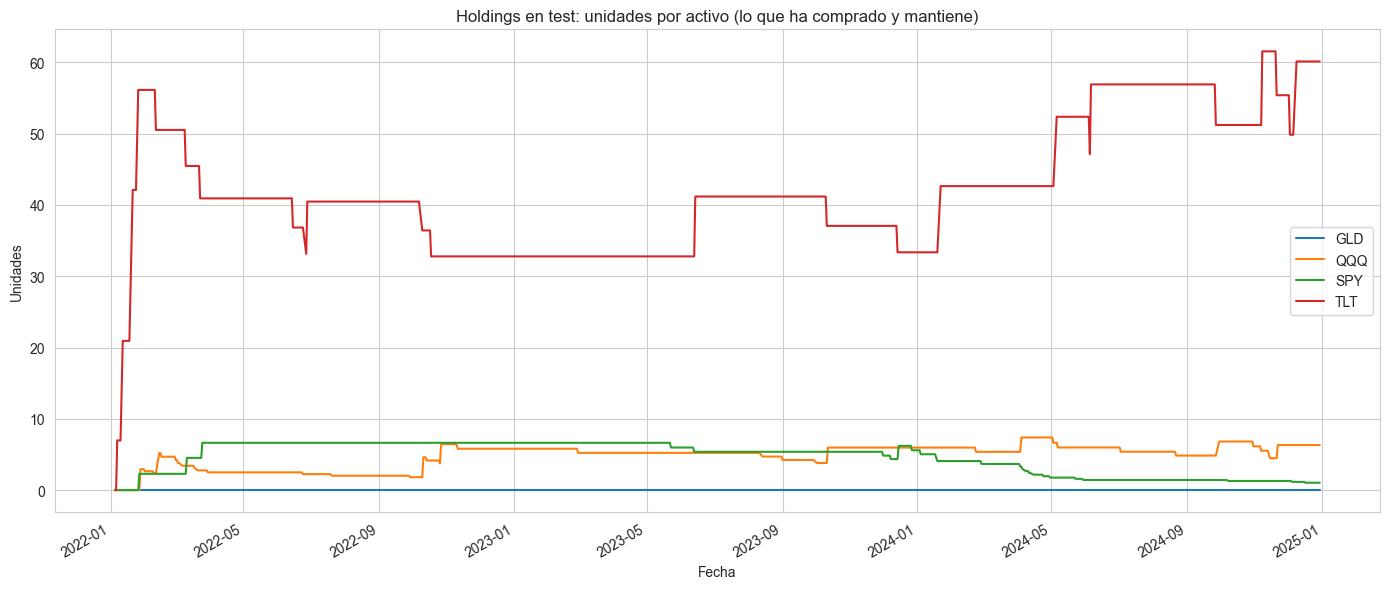

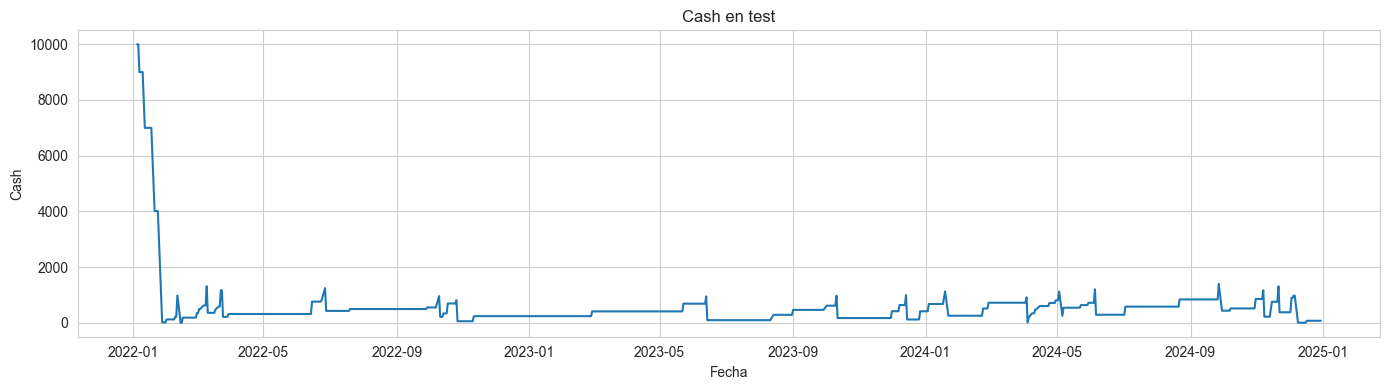

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_test_holdings(env_test, agent, greedy=True):
    """
    Ejecuta un episodio completo en env_test y grafica:
      - Unidades (holdings) de cada activo a lo largo del tiempo.
      - (Opcional) cash y valor de cartera.

    Funciona con tu PortfolioEnv (usa env_test.holdings, env_test.balance, env_test.portfolio_history).
    """
    # Forzamos política greedy en test si se pide
    eps_backup = getattr(agent, "epsilon", None)
    if greedy and eps_backup is not None:
        agent.epsilon = 0.0

    state, _ = env_test.reset()
    done = False

    dates = []
    holdings_hist = []
    cash_hist = []
    portval_hist = []

    while True:
        # Guardamos el estado actual (antes del step) para no salirnos del índice
        dates.append(env_test.features.index[env_test.current_step])
        holdings_hist.append(env_test.holdings.copy())
        cash_hist.append(float(env_test.balance))
        portval_hist.append(float(env_test.portfolio_history[-1]))

        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env_test.step(action)
        state = next_state
        done = terminated or truncated

        if done:
            break

    # Restaurar epsilon
    if greedy and eps_backup is not None:
        agent.epsilon = eps_backup

    # DataFrame con holdings
    holdings_df = pd.DataFrame(holdings_hist, index=dates, columns=env_test.assets)

    # Gráfica holdings por activo
    ax = holdings_df.plot(figsize=(14, 6))
    ax.set_title("Holdings en test: unidades por activo (lo que ha comprado y mantiene)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Unidades")
    plt.tight_layout()
    plt.show()

    # Opcional: cash y valor de cartera 
    plt.figure(figsize=(14, 4))
    plt.plot(dates, cash_hist)
    plt.title("Cash en test")
    plt.xlabel("Fecha")
    plt.ylabel("Cash")
    plt.tight_layout()
    plt.show()


    return holdings_df

holdings_df = plot_test_holdings(env_test, agent, greedy=True)
